In [7]:
from pathlib import Path
import sys

sys.path.append(str(Path().resolve().parent))


                           

                                                            
                                            

BASE_DIR = Path().resolve()
PROJECT_ROOT = BASE_DIR.parent   #to go un up the the root
DATA_DIR = PROJECT_ROOT / "data"

# Root directory of dataset
root = Path(DATA_DIR)


import numpy as np
import matplotlib.pyplot as plt 
from scipy.signal import find_peaks
import pandas as pd

In [8]:


def build_df(root):

    label_map = {
        1: "correct",
        2: "fast",
        3: "low_amplitude"
    }

    dfs = []   # store all partial dataframes

    for subject_dir in root.glob("s*"):
        for exercise_dir in subject_dir.glob("e*"):
            for unit_dir in exercise_dir.glob("u*"):

                file_path = unit_dir / "test.txt"

                df = pd.read_csv(file_path, sep=";")

                df["subject"] = subject_dir.name
                df["exercise"] = exercise_dir.name
                df["unit"] = unit_dir.name

                

                label_map = {
                    0: "correct",
                    1: "fast",
                    2: "low_amplitude"
                }

                segment_length = len(df) // 30

                df["execution_type"] = None

                for i in range(30):
                    start = i * segment_length
                    end = (i + 1) * segment_length

                    label_group = i // 10
                    label = label_map[label_group]

                    df.loc[start:end, "execution_type"] = label

                dfs.append(df)   # collect dataframe

    final_df = pd.concat(dfs, ignore_index=True)

    return final_df

In [9]:
df=build_df(root)


In [10]:
df[(df['subject']=='s1') & (df['exercise']=='e1') ]

,time index,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,mag_x,mag_y,mag_z,subject,exercise,unit,execution_type
0,1,-9.685645,-1.645149,0.505022,-0.020696,0.009202,-0.008566,0.589728,0.453403,-0.075234,s1,e1,u1,correct
1,2,-9.648184,-1.645353,0.513125,-0.008165,-0.001407,-0.003256,0.587024,0.453644,-0.075593,s1,e1,u1,correct
2,3,-9.700570,-1.615223,0.512321,-0.004447,0.011059,-0.008589,0.589691,0.454598,-0.075525,s1,e1,u1,correct
3,4,-9.685627,-1.630183,0.497591,-0.026110,0.009183,-0.008554,0.589240,0.452864,-0.074705,s1,e1,u1,correct
4,5,-9.655697,-1.630194,0.460742,-0.008109,0.001231,-0.005950,0.589647,0.452882,-0.076429,s1,e1,u1,correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29740,5945,-4.223868,-7.541800,-4.607269,-0.016858,-0.001904,-0.011902,0.003246,0.725318,0.231512,s1,e1,u5,None
29741,5946,-4.253123,-7.531929,-4.612775,-0.006980,-0.021866,-0.013705,0.005410,0.724710,0.231259,s1,e1,u5,None
29742,5947,-4.233624,-7.536894,-4.607502,-0.013551,-0.001552,0.000465,0.004094,0.725666,0.233084,s1,e1,u5,None
29743,5948,-4.228771,-7.517463,-4.622438,-0.020245,-0.013049,-0.019876,0.004089,0.724876,0.232979,s1,e1,u5,None


In [11]:
merged_df = df.pivot(
    index=["subject", "exercise", "time index"],
    columns="unit",
    values=["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z", "mag_x", "mag_y", "mag_z"]
)

merged_df.columns = [f"{sensor}_{unit}" for sensor, unit in merged_df.columns]
merged_df = merged_df.reset_index()




In [12]:
subject2ex1=merged_df[(merged_df['subject']=='s2') & (merged_df['exercise']=='e1') ]

In [13]:
import matplotlib.pyplot as plt
import numpy as np

#### accelerometer magnitude of exercise 2 for subject 2 of one sensor unit

exercise 2 is moving the leg, the most used sensor shuold be only s2

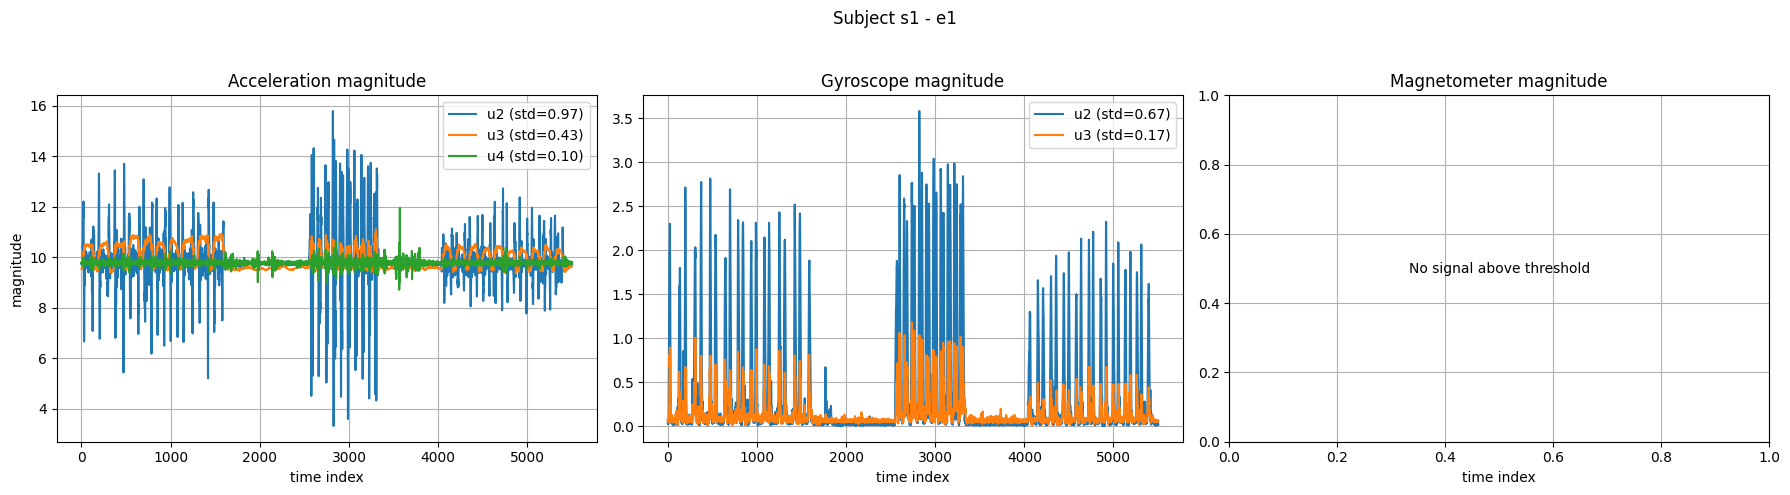

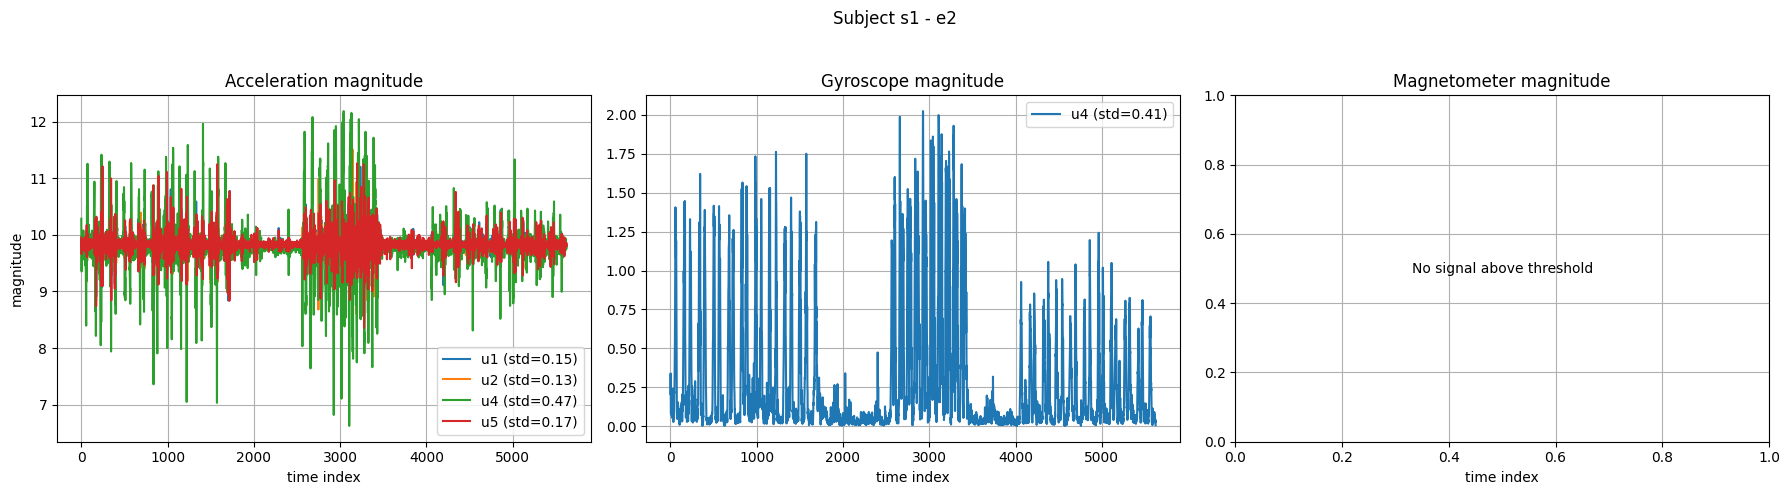

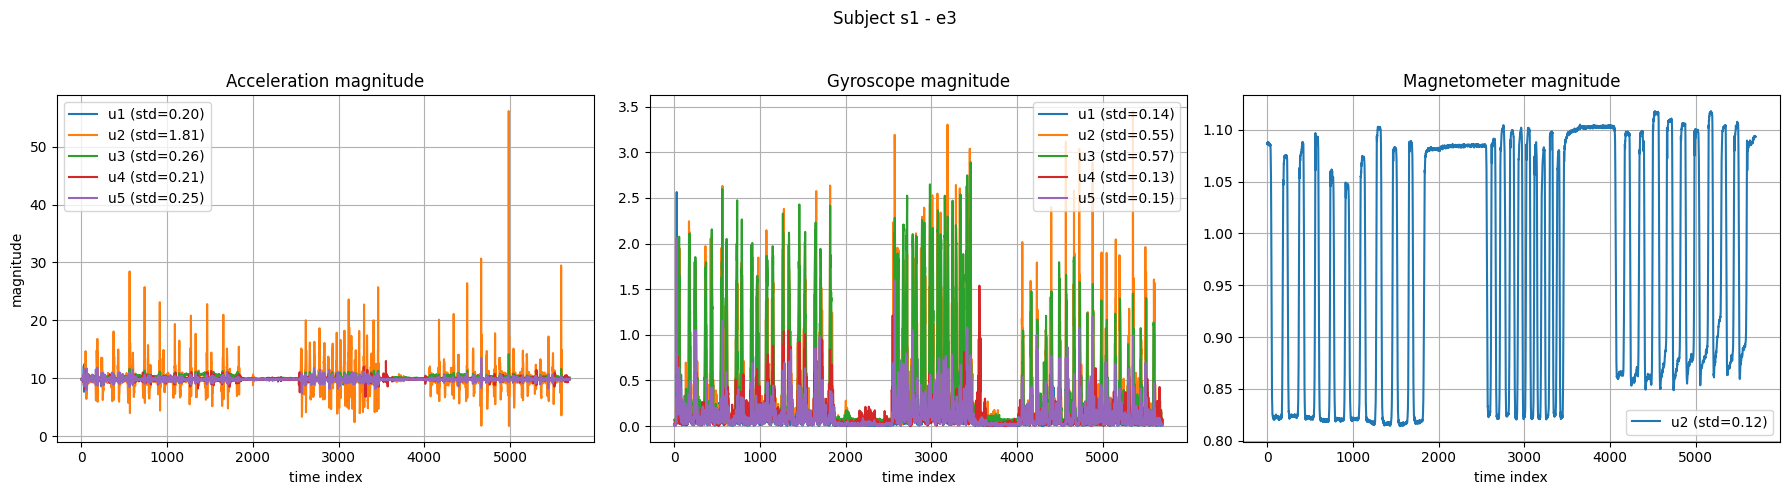

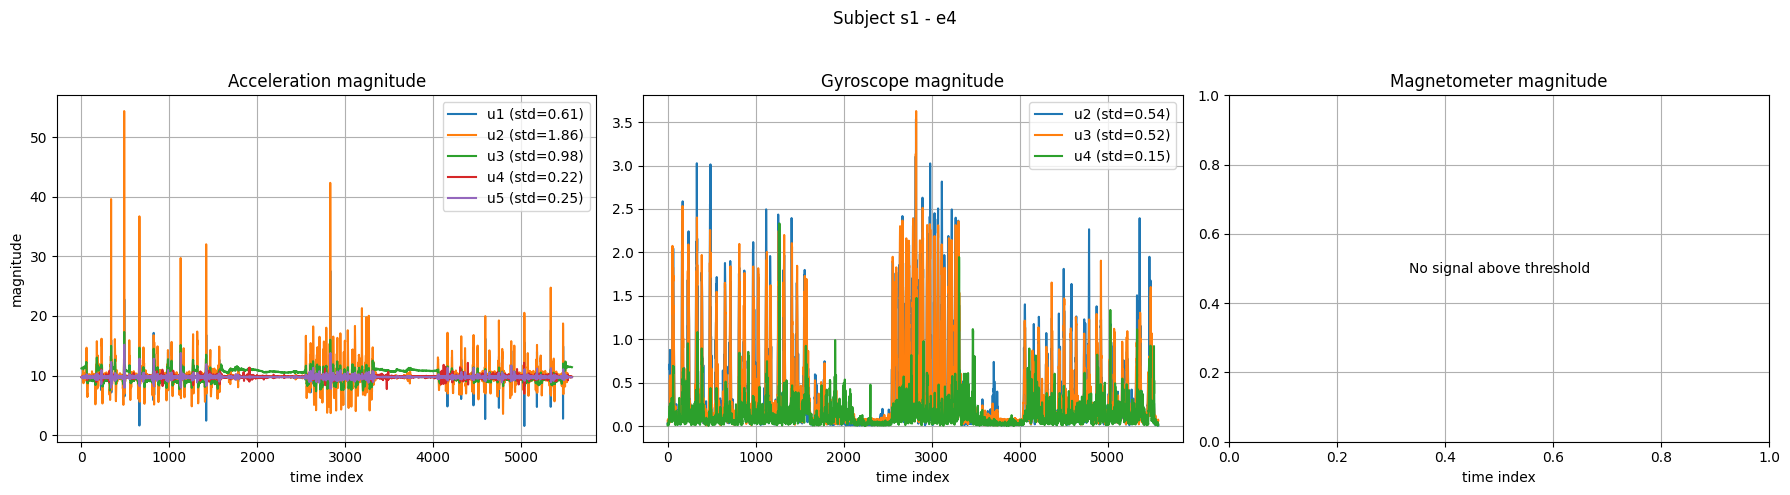

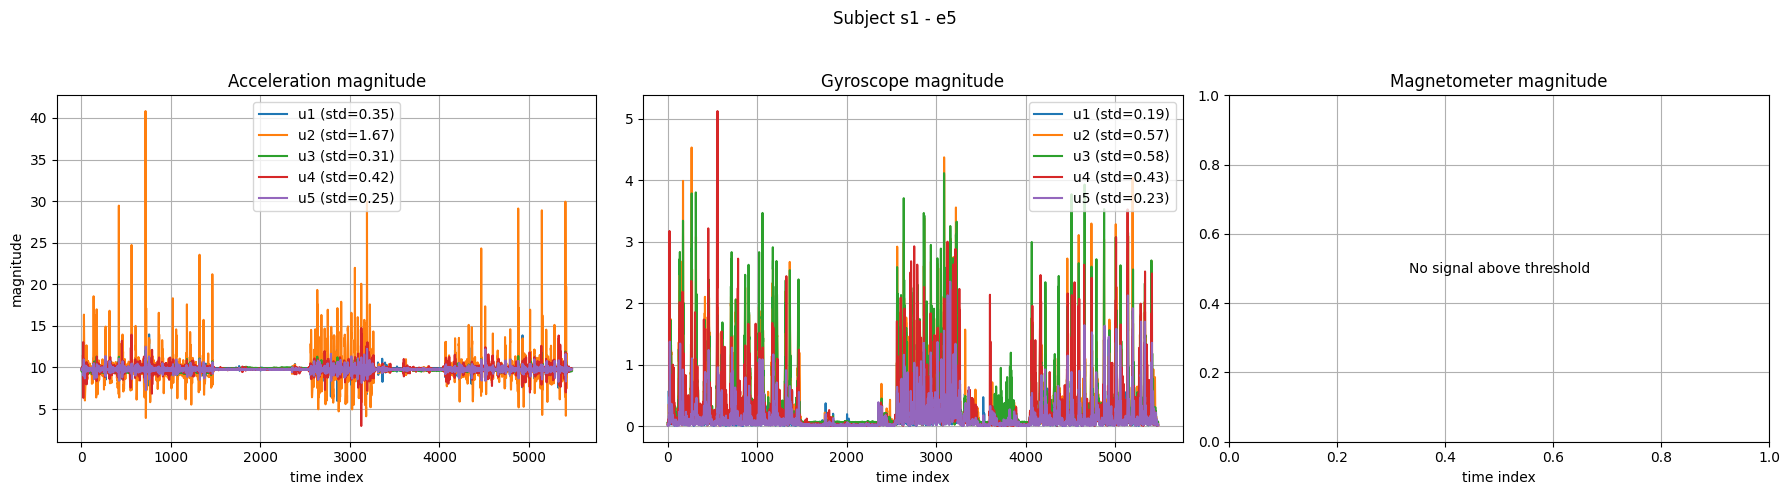

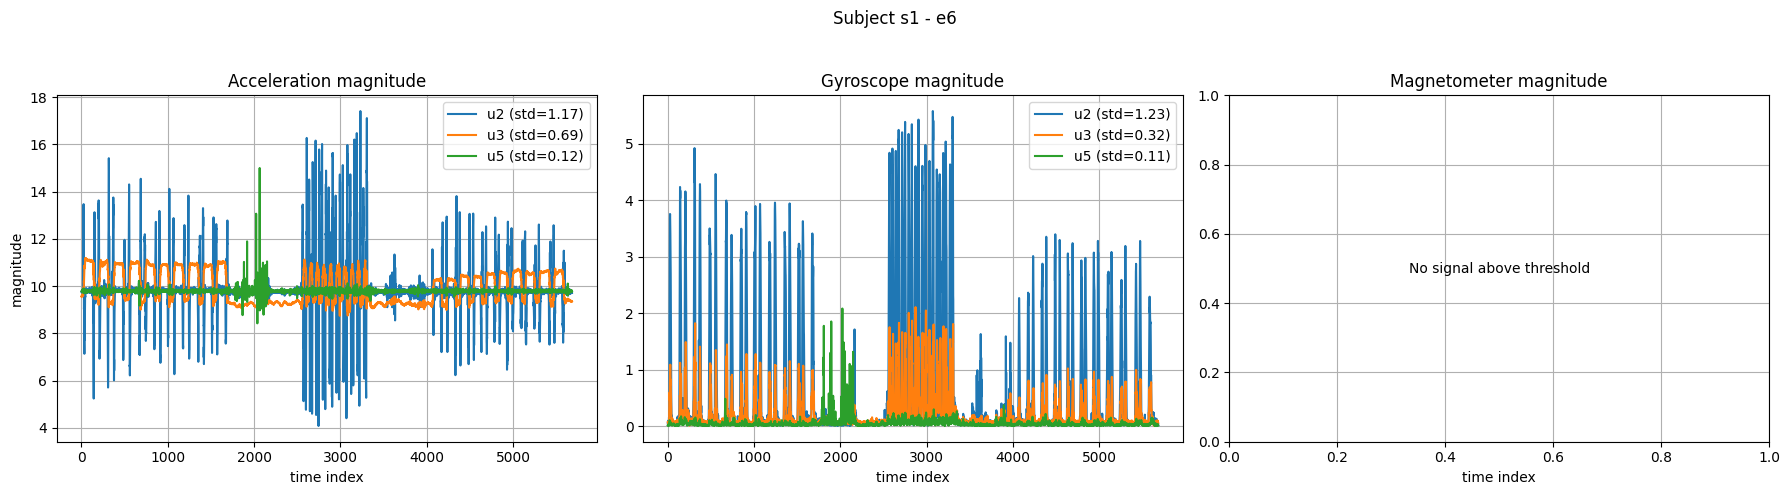

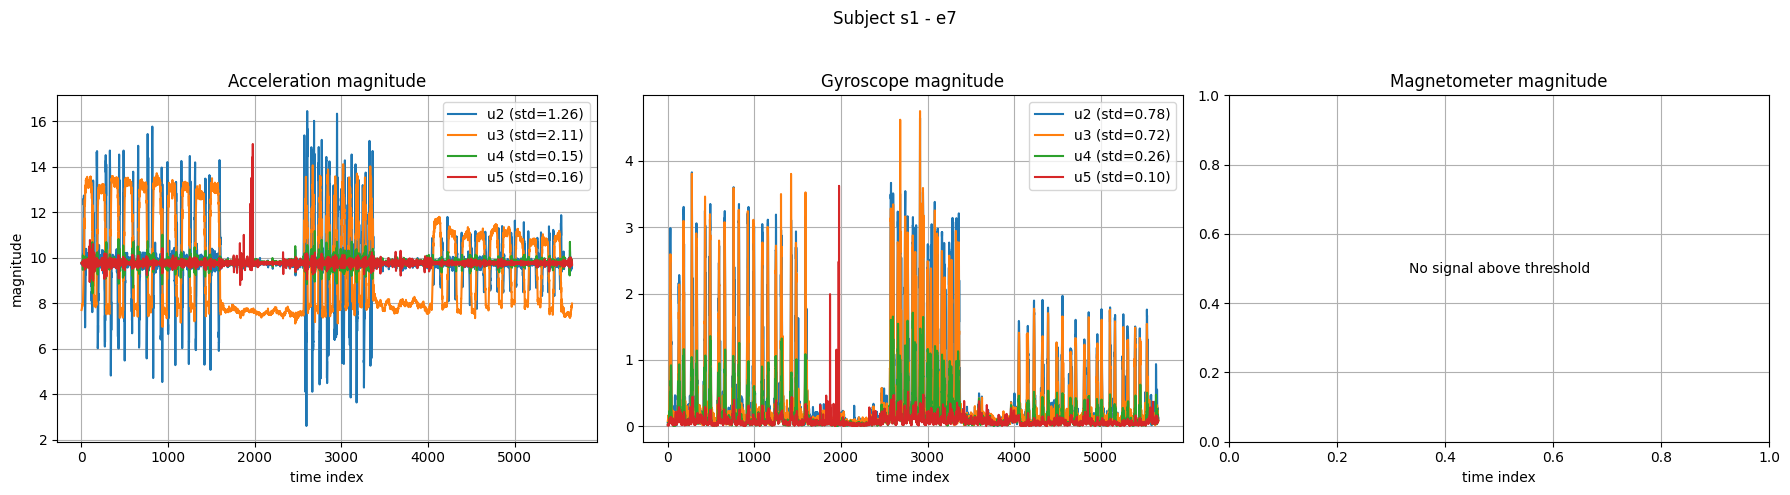

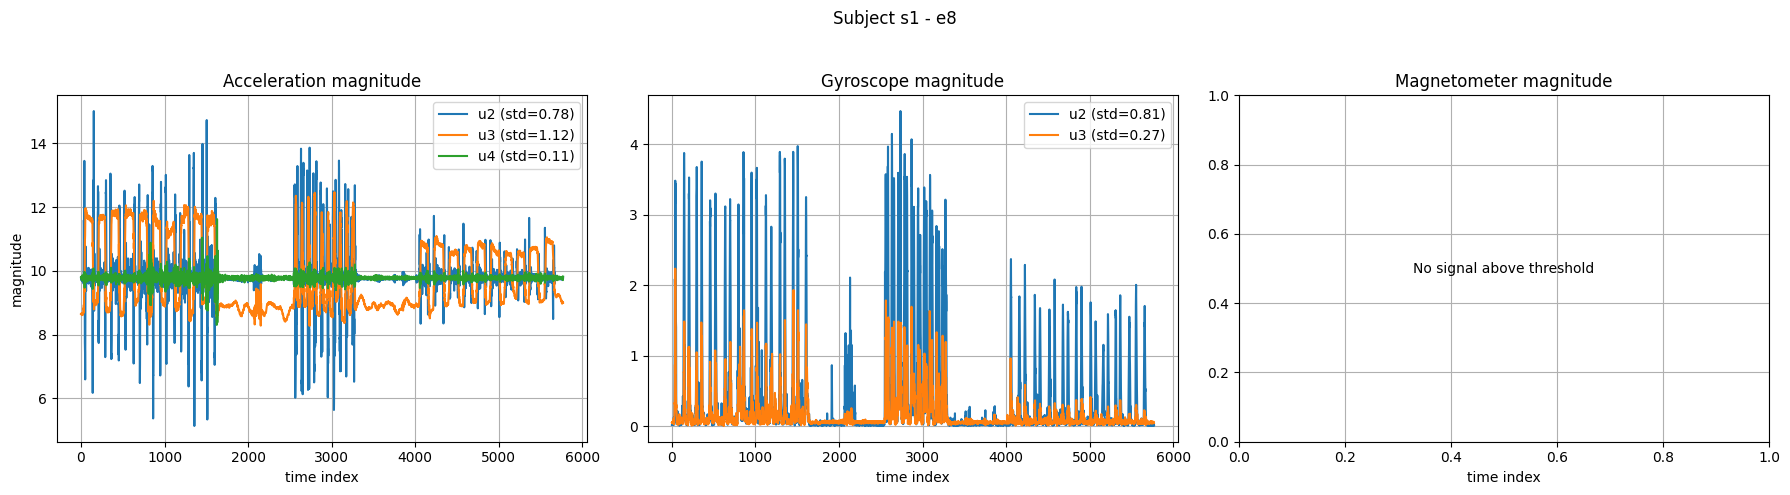

In [14]:
subject = merged_df[merged_df['subject'] == 's3']
exercises = ['e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8']

for exercise in exercises:
    subject_ex = subject[subject['exercise'] == exercise].copy()

    if subject_ex.empty:
        print(f"No data for {exercise}")
        continue

    # Compute magnitudes for all units
    for u in range(1, 6):
        subject_ex[f"acc_mag_u{u}"] = np.sqrt(
            subject_ex[f"acc_x_u{u}"]**2 +
            subject_ex[f"acc_y_u{u}"]**2 +
            subject_ex[f"acc_z_u{u}"]**2
        )

        subject_ex[f"gyr_mag_u{u}"] = np.sqrt(
            subject_ex[f"gyr_x_u{u}"]**2 +
            subject_ex[f"gyr_y_u{u}"]**2 +
            subject_ex[f"gyr_z_u{u}"]**2
        )

        subject_ex[f"mag_mag_u{u}"] = np.sqrt(
            subject_ex[f"mag_x_u{u}"]**2 +
            subject_ex[f"mag_y_u{u}"]**2 +
            subject_ex[f"mag_z_u{u}"]**2
        )

    threshold = 0.1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Subject s1 - {exercise}")

    sensor_info = [
        ("acc", "Acceleration magnitude", axes[0]),
        ("gyr", "Gyroscope magnitude", axes[1]),
        ("mag", "Magnetometer magnitude", axes[2]),
    ]

    anything_plotted = False

    for sensor_prefix, title, ax in sensor_info:
        plotted_here = False

        for u in range(1, 6):
            std = subject_ex[f"{sensor_prefix}_mag_u{u}"].std()

            if std > threshold:
                ax.plot(
                    subject_ex["time index"],
                    subject_ex[f"{sensor_prefix}_mag_u{u}"],
                    label=f"u{u} (std={std:.2f})"
                )
                plotted_here = True
                anything_plotted = True

        ax.set_title(title)
        ax.set_xlabel("time index")
        ax.grid(True)

        if sensor_prefix == "acc":
            ax.set_ylabel("magnitude")

        if plotted_here:
            ax.legend()
        else:
            ax.text(
                0.5, 0.5, "No signal above threshold",
                transform=ax.transAxes,
                ha="center", va="center"
            )

    if anything_plotted:
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
    else:
        plt.close()
        print(f"No sensor exceeded threshold for {exercise}")

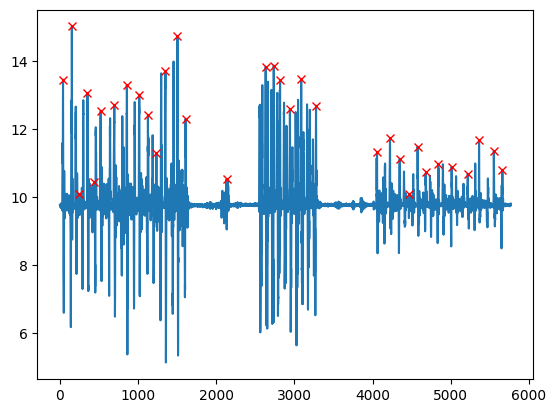

In [15]:
signal = subject_ex["acc_mag_u2"].to_numpy()
peaks, _ = find_peaks(signal, distance=80, prominence=0.6)

plt.plot(signal)
plt.plot(peaks, signal[peaks], "xr")
plt.show()



### this is what we use for the detection 

In [16]:
subject_ex

,subject,exercise,time index,acc_x_u1,acc_x_u2,acc_x_u3,acc_x_u4,acc_x_u5,acc_y_u1,acc_y_u2,...,mag_mag_u2,acc_mag_u3,gyr_mag_u3,mag_mag_u3,acc_mag_u4,gyr_mag_u4,mag_mag_u4,acc_mag_u5,gyr_mag_u5,mag_mag_u5
129146,s3,e8,1,1.052081,-9.707067,3.826224,3.148929,2.538788,-8.903480,0.282587,...,0.797463,8.647838,0.048730,0.865795,9.790473,0.001510,0.902372,9.757024,0.008091,0.856135
129147,s3,e8,2,1.052068,-9.684566,3.825560,3.139137,2.550995,-8.903427,0.297343,...,0.797745,8.651166,0.046317,0.865380,9.780257,0.017981,0.902304,9.783278,0.015031,0.855811
129148,s3,e8,3,1.097042,-9.662262,3.841858,3.134169,2.531473,-8.888698,0.297074,...,0.796717,8.651614,0.058253,0.865720,9.789780,0.010146,0.902128,9.765887,0.015027,0.855801
129149,s3,e8,4,1.112064,-9.677180,3.837770,3.129284,2.533906,-8.873878,0.282464,...,0.796237,8.658656,0.057358,0.866841,9.804834,0.009290,0.902736,9.777134,0.006097,0.854596
129150,s3,e8,5,1.089576,-9.692179,3.827072,3.143970,2.543649,-8.873720,0.282437,...,0.797338,8.648232,0.060798,0.866009,9.769453,0.015817,0.903790,9.739163,0.020492,0.855605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134909,s3,e8,5764,1.037770,-9.705793,4.062612,2.878828,2.519102,-8.931727,0.505246,...,0.788133,8.995906,0.056910,0.870399,9.817919,0.015863,0.914069,9.747297,0.010738,0.856150
134910,s3,e8,5765,1.023069,-9.676151,4.082921,2.864144,2.519127,-8.812433,0.475310,...,0.787009,8.992210,0.062025,0.870253,9.782450,0.013642,0.914098,9.759905,0.021554,0.856468
134911,s3,e8,5766,1.068171,-9.683571,4.085911,2.869219,2.504449,-8.745564,0.482779,...,0.787687,9.014297,0.062498,0.870841,9.708161,0.016363,0.913141,9.731607,0.012907,0.855258
134912,s3,e8,5767,1.082741,-9.661278,4.093063,2.861648,2.499637,-8.947065,0.467780,...,0.787944,9.019986,0.056732,0.869587,9.782426,0.032916,0.914800,9.777503,0.005593,0.856014


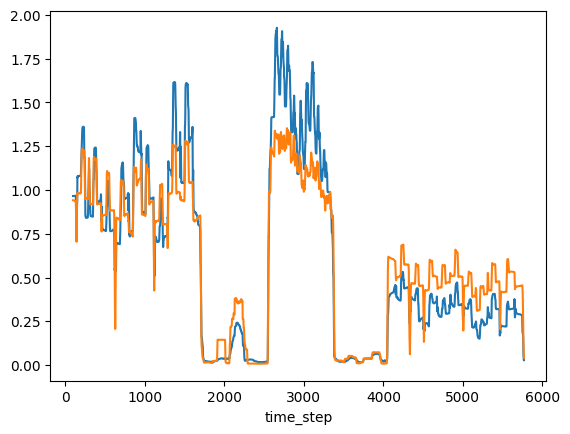

In [17]:
columns=["acc_mag_u2", 'gyr_mag_u2']

for column in columns:
    signal = subject_ex[column].to_numpy()
    energy = pd.Series(signal).rolling(100).std()

    plt.plot(energy)
    plt.xlabel('time_step')
    

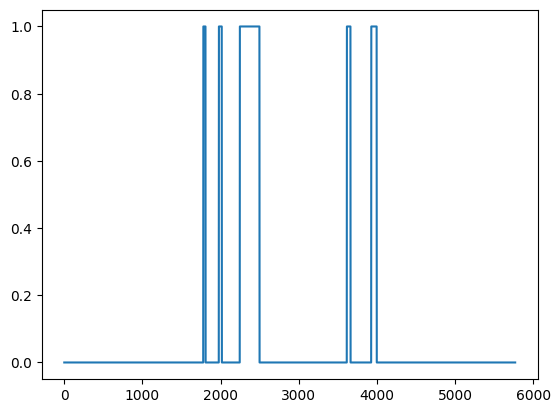

In [18]:
energy = pd.Series(signal).rolling(100, center=True).std()
energy = energy.bfill().ffill()

idle_mask = energy < 0.013

plt.plot(idle_mask)

changes = idle_mask.ne(idle_mask.shift())

ind = []

for i, value in enumerate(changes):
    if value is True and i<4100:
        ind.append(i)

ind.remove(0)



In [19]:
print(energy.describe())
print()
# The idle periods are the lowest values in the distribution
# A natural cutoff is somewhere between the minimum and the first quartile
print("1st percentile:", energy.quantile(0.01))
print("5th percentile:", energy.quantile(0.05))
print("10th percentile:", energy.quantile(0.10))

count    5768.000000
mean        0.597332
std         0.410553
min         0.007237
25%         0.223993
50%         0.540491
75%         0.954248
max         1.352869
dtype: float64

1st percentile: 0.007710968006272086
5th percentile: 0.009295490987434535
10th percentile: 0.016761439117905737


In [20]:
subject_ex

,subject,exercise,time index,acc_x_u1,acc_x_u2,acc_x_u3,acc_x_u4,acc_x_u5,acc_y_u1,acc_y_u2,...,mag_mag_u2,acc_mag_u3,gyr_mag_u3,mag_mag_u3,acc_mag_u4,gyr_mag_u4,mag_mag_u4,acc_mag_u5,gyr_mag_u5,mag_mag_u5
129146,s3,e8,1,1.052081,-9.707067,3.826224,3.148929,2.538788,-8.903480,0.282587,...,0.797463,8.647838,0.048730,0.865795,9.790473,0.001510,0.902372,9.757024,0.008091,0.856135
129147,s3,e8,2,1.052068,-9.684566,3.825560,3.139137,2.550995,-8.903427,0.297343,...,0.797745,8.651166,0.046317,0.865380,9.780257,0.017981,0.902304,9.783278,0.015031,0.855811
129148,s3,e8,3,1.097042,-9.662262,3.841858,3.134169,2.531473,-8.888698,0.297074,...,0.796717,8.651614,0.058253,0.865720,9.789780,0.010146,0.902128,9.765887,0.015027,0.855801
129149,s3,e8,4,1.112064,-9.677180,3.837770,3.129284,2.533906,-8.873878,0.282464,...,0.796237,8.658656,0.057358,0.866841,9.804834,0.009290,0.902736,9.777134,0.006097,0.854596
129150,s3,e8,5,1.089576,-9.692179,3.827072,3.143970,2.543649,-8.873720,0.282437,...,0.797338,8.648232,0.060798,0.866009,9.769453,0.015817,0.903790,9.739163,0.020492,0.855605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134909,s3,e8,5764,1.037770,-9.705793,4.062612,2.878828,2.519102,-8.931727,0.505246,...,0.788133,8.995906,0.056910,0.870399,9.817919,0.015863,0.914069,9.747297,0.010738,0.856150
134910,s3,e8,5765,1.023069,-9.676151,4.082921,2.864144,2.519127,-8.812433,0.475310,...,0.787009,8.992210,0.062025,0.870253,9.782450,0.013642,0.914098,9.759905,0.021554,0.856468
134911,s3,e8,5766,1.068171,-9.683571,4.085911,2.869219,2.504449,-8.745564,0.482779,...,0.787687,9.014297,0.062498,0.870841,9.708161,0.016363,0.913141,9.731607,0.012907,0.855258
134912,s3,e8,5767,1.082741,-9.661278,4.093063,2.861648,2.499637,-8.947065,0.467780,...,0.787944,9.019986,0.056732,0.869587,9.782426,0.032916,0.914800,9.777503,0.005593,0.856014


Idle periods found: [(np.int64(1818), np.int64(2176)), (np.int64(3392), np.int64(3991))]


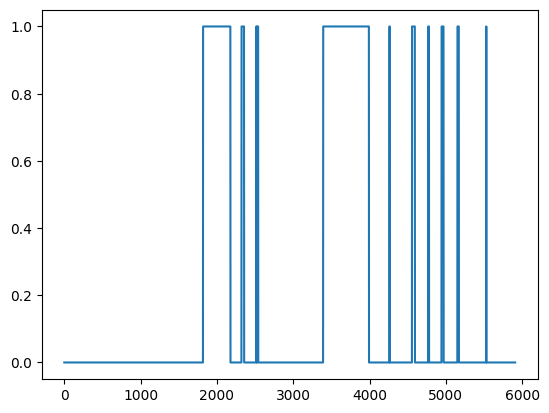

In [27]:
signal = subject_ex['acc_mag_u4'].to_numpy()
energy = pd.Series(signal).rolling(100, center=True).std()
energy = energy.bfill().ffill()

# Data-driven threshold: midpoint between 10th and 25th percentile
threshold = (energy.quantile(0.10) + energy.quantile(0.25)) / 2

idle_mask = energy < threshold

plt.plot(idle_mask)

# Find contiguous idle regions and extract their start/end indices
groups = (idle_mask != idle_mask.shift()).cumsum()
idle_groups = idle_mask[idle_mask == True].groupby(groups[idle_mask == True])
idle_periods = [(group.index[0], group.index[-1]) for _, group in idle_groups]

# Keep only the 2 longest idle periods (the real rest gaps)
idle_periods = sorted(idle_periods, key=lambda x: x[1] - x[0], reverse=True)[:2]
idle_periods = sorted(idle_periods, key=lambda x: x[0])  # re-sort by time

print("Idle periods found:", idle_periods)

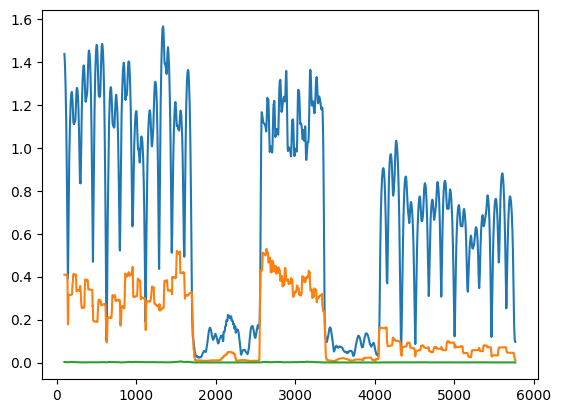

In [22]:
columns=["acc_mag_u3", 'gyr_mag_u3', 'mag_mag_u3']

for column in columns:
    signal = subject_ex[column].to_numpy()
    energy = pd.Series(signal).rolling(100).std()

    plt.plot(energy)

    

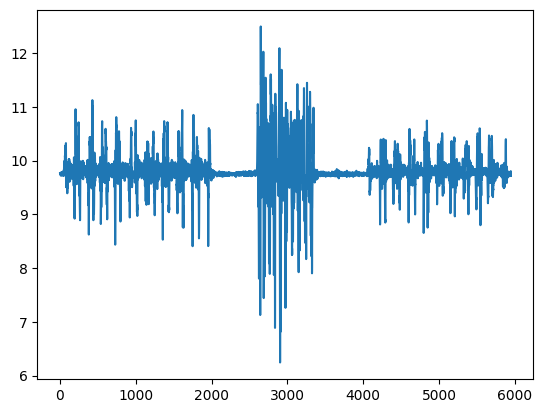

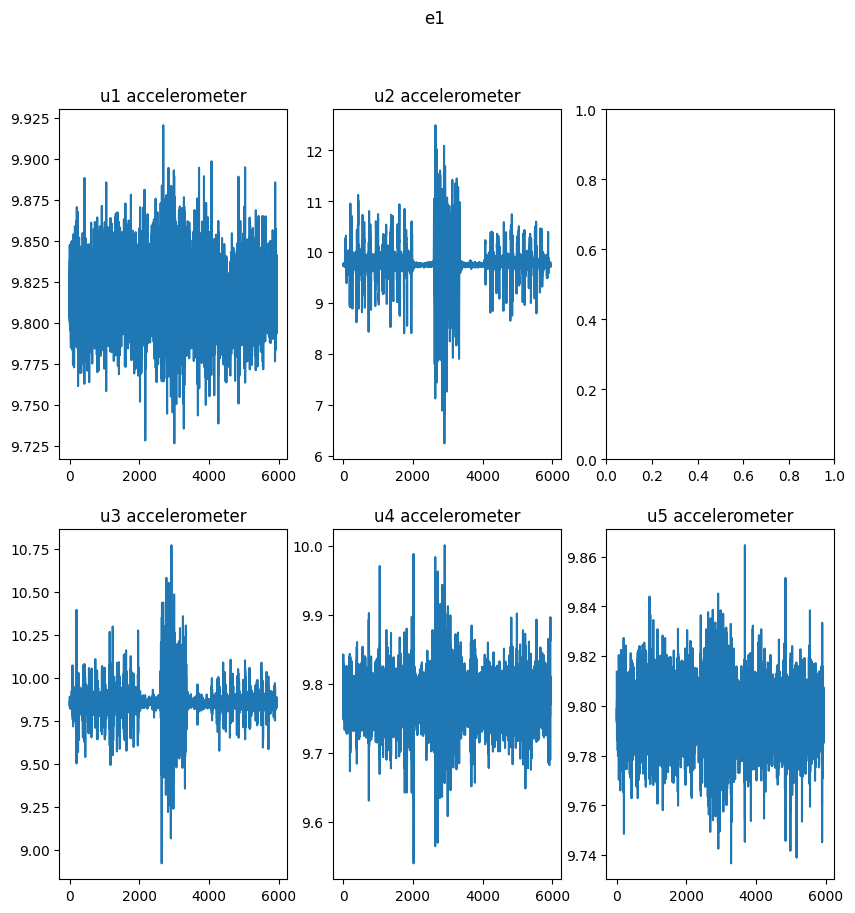

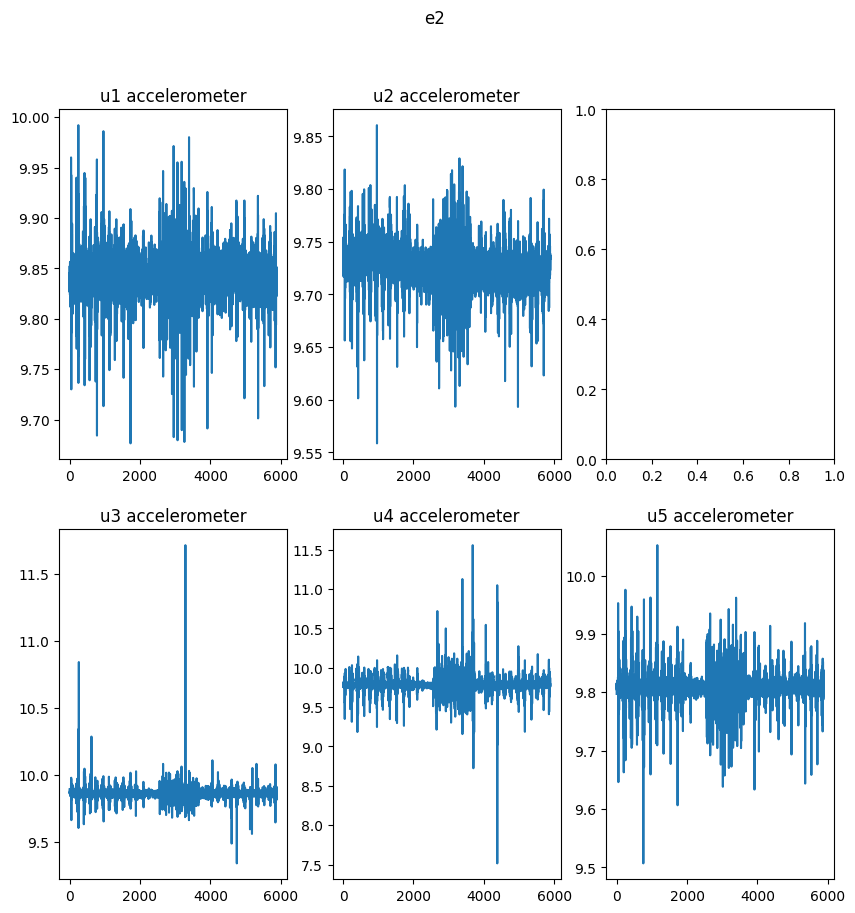

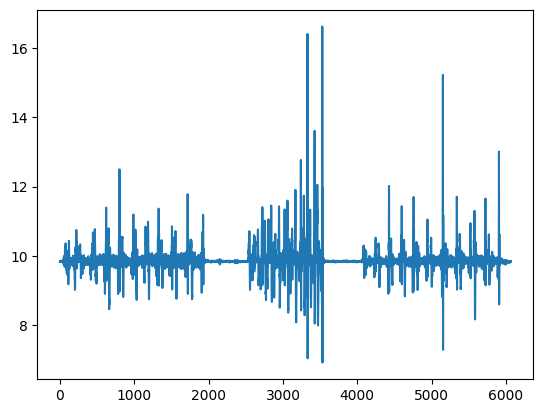

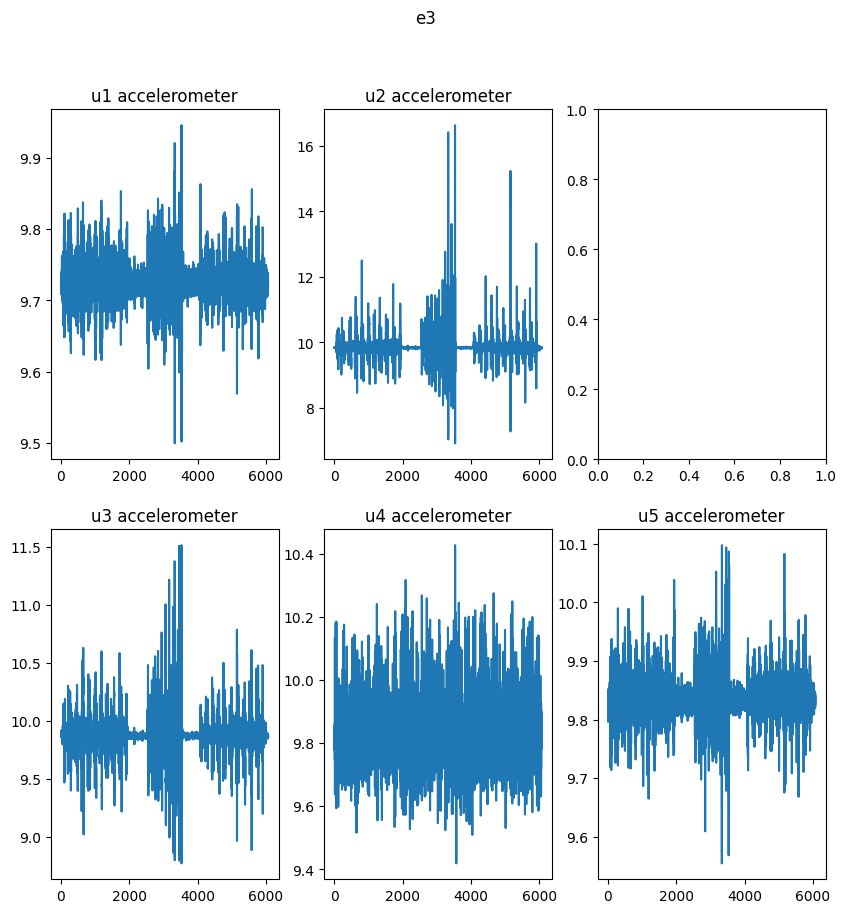

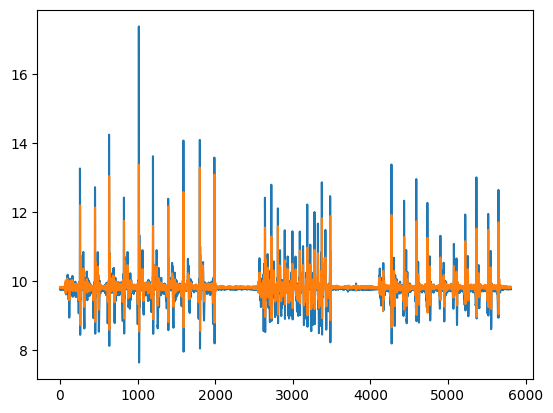

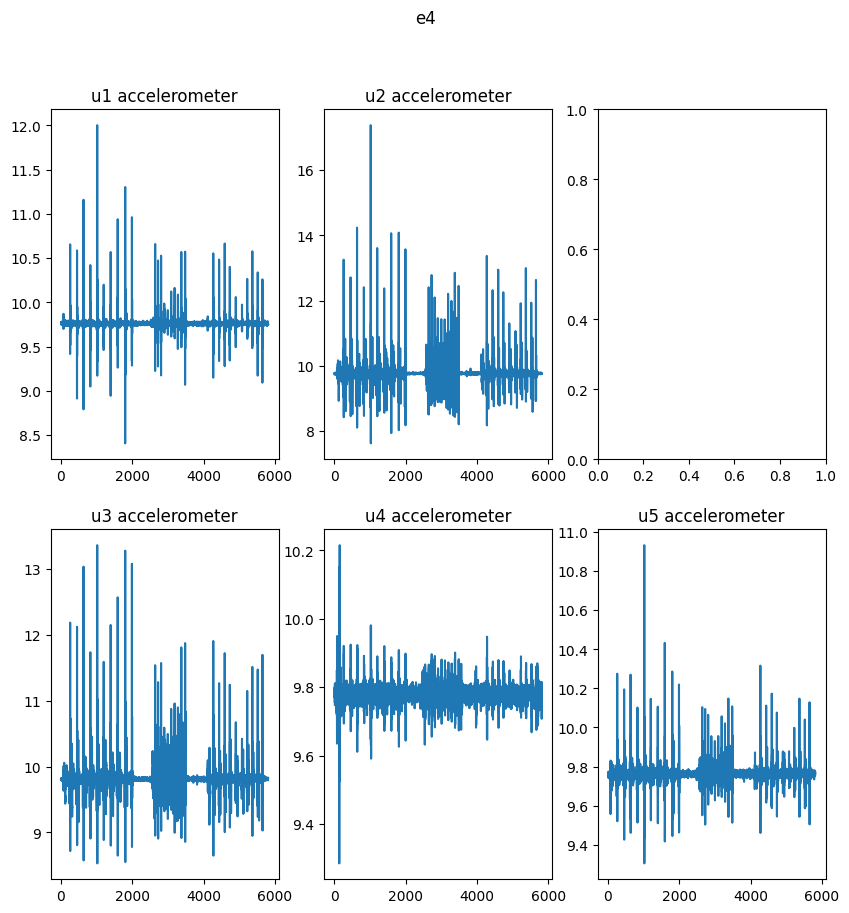

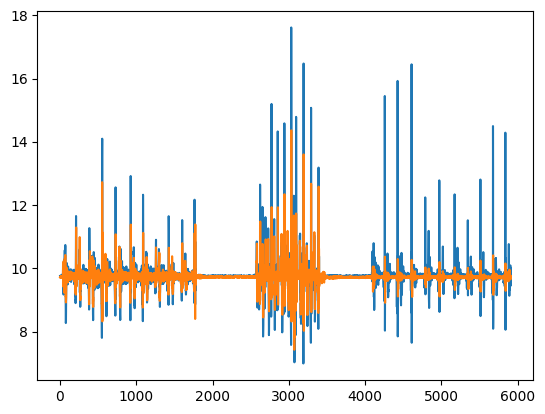

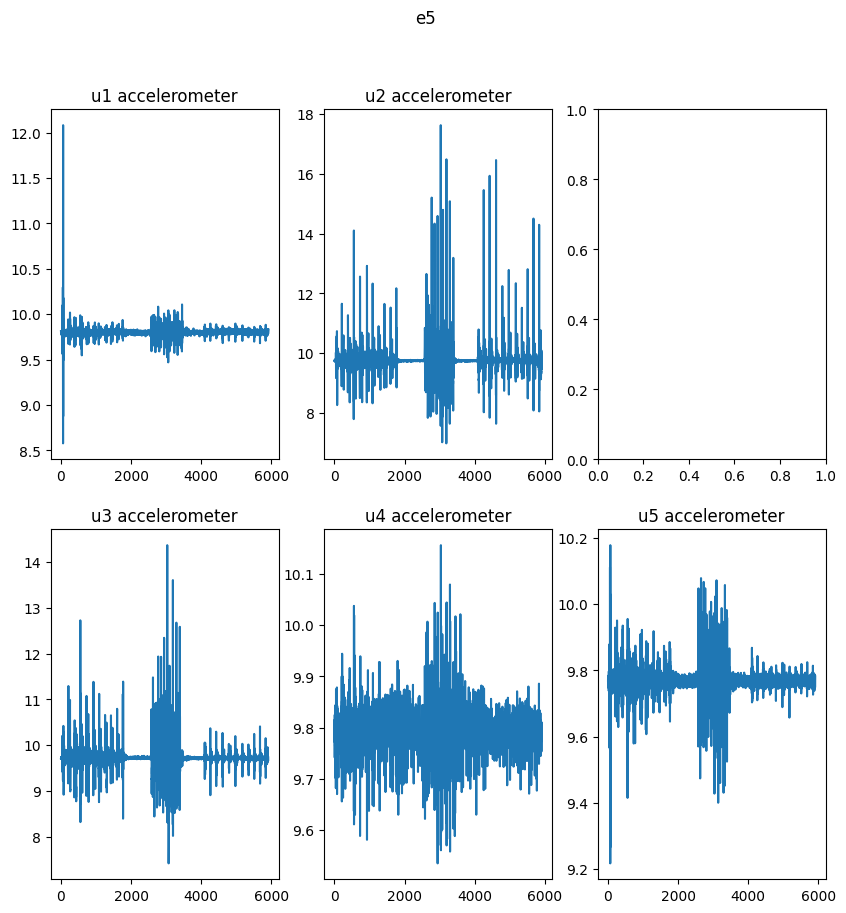

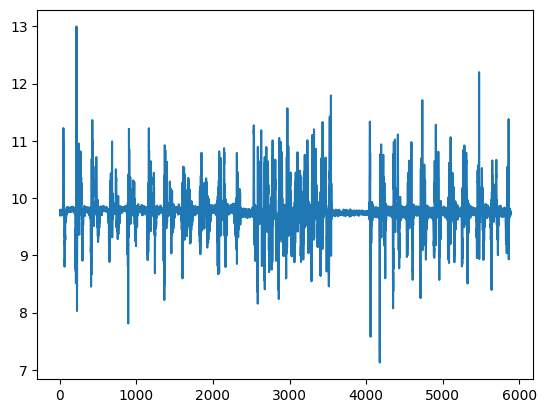

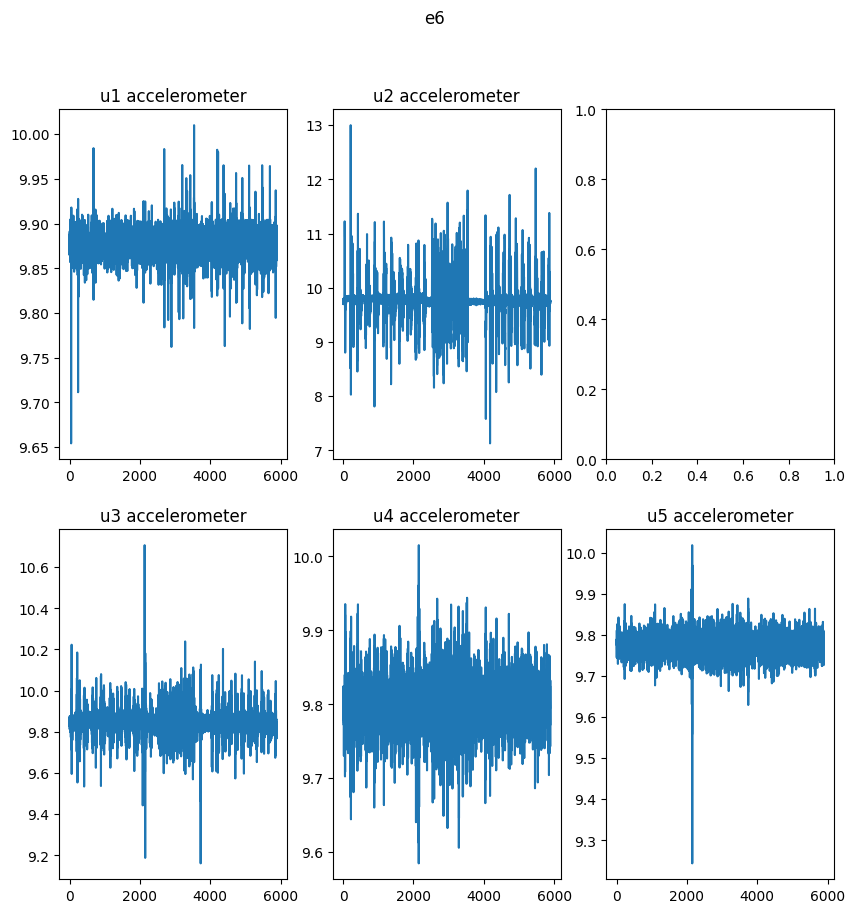

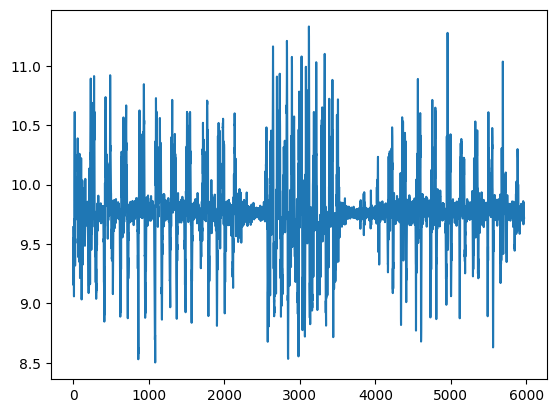

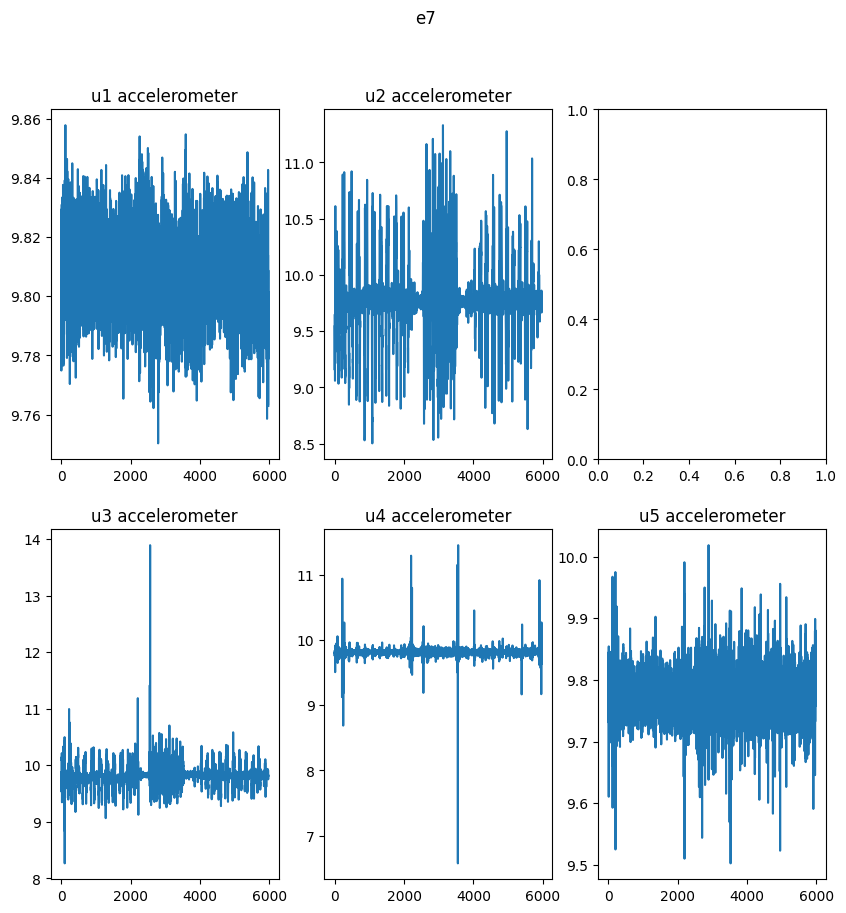

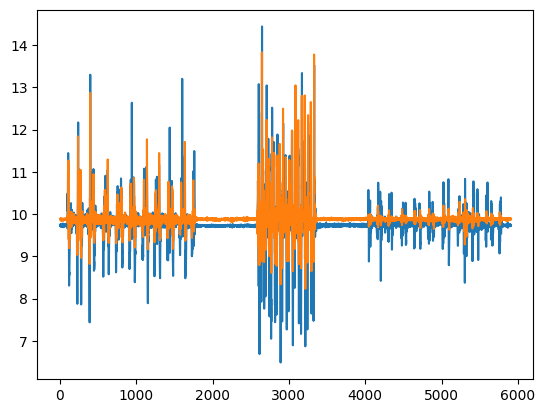

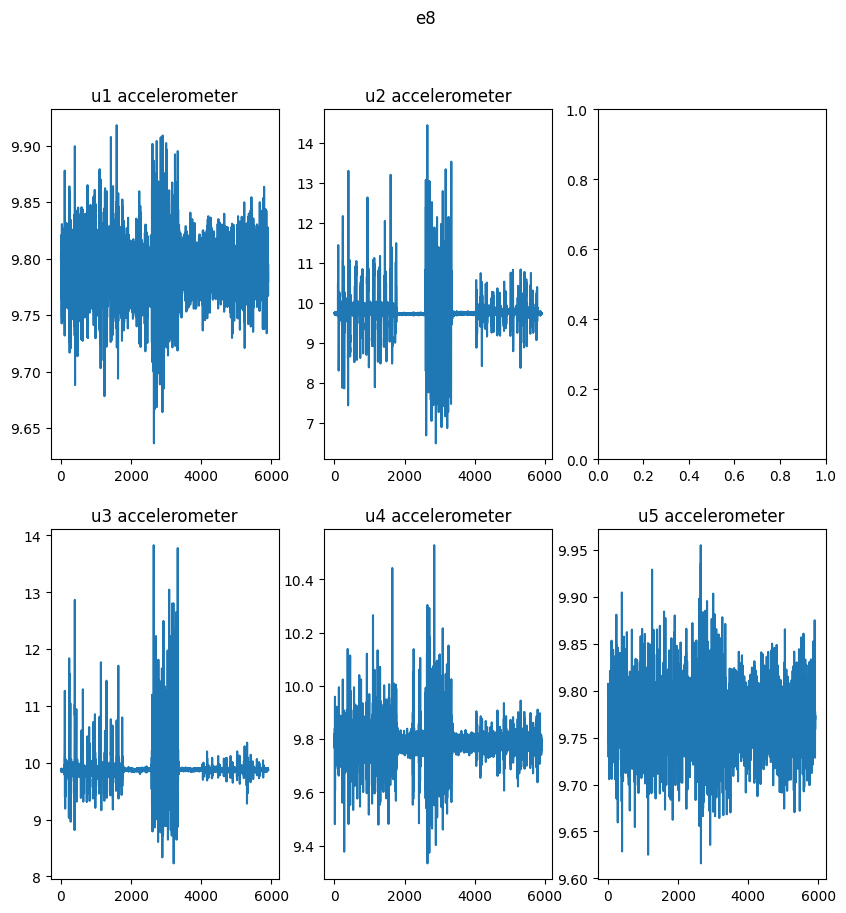

In [23]:

subject=merged_df[merged_df['subject']=='s1']

exercises = ['e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8']

for exercise in exercises:
    subject_ex = subject[subject['exercise'] == exercise].copy()
    
    subject_ex["acc_mag_u1"] = np.sqrt(      
        subject_ex["acc_x_u1"]**2 +
        subject_ex["acc_y_u1"]**2 +
        subject_ex["acc_z_u1"]**2
    )

    subject_ex["acc_mag_u2"] = np.sqrt(      
        subject_ex["acc_x_u2"]**2 +
        subject_ex["acc_y_u2"]**2 +
        subject_ex["acc_z_u2"]**2
    )

    subject_ex["acc_mag_u3"] = np.sqrt(      
        subject_ex["acc_x_u3"]**2 +
        subject_ex["acc_y_u3"]**2 +
        subject_ex["acc_z_u3"]**2
    )

    subject_ex["acc_mag_u4"] = np.sqrt(      
        subject_ex["acc_x_u4"]**2 +
        subject_ex["acc_y_u4"]**2 +
        subject_ex["acc_z_u4"]**2
    )

    subject_ex["acc_mag_u5"] = np.sqrt(      
        subject_ex["acc_x_u5"]**2 +
        subject_ex["acc_y_u5"]**2 +
        subject_ex["acc_z_u5"]**2
    )

    threshold = 0.2   # example threshold

    for u in range(1,6):

        std = subject_ex[f"acc_mag_u{u}"].std()

        if std > threshold:
            plt.plot(subject_ex["time index"], subject_ex[f"acc_mag_u{u}"],
                    label=f"u{u} (std={std:.2f})")



    fig, axes= plt.subplots(ncols=3, nrows=2, figsize=(10,10))
    fig.suptitle(exercise)
    axes[0,0].plot(subject_ex["time index"], subject_ex["acc_mag_u1"])
    axes[0,0].set_title('u1 accelerometer')

    axes[0,1].plot(subject_ex["time index"], subject_ex["acc_mag_u2"])
    axes[0,1].set_title('u2 accelerometer')

    axes[1,0].plot(subject_ex["time index"], subject_ex["acc_mag_u3"])
    axes[1,0].set_title('u3 accelerometer')


    axes[1,1].plot(subject_ex["time index"],subject_ex["acc_mag_u4"])
    axes[1,1].set_title('u4 accelerometer')


    axes[1,2].plot(subject_ex["time index"], subject_ex["acc_mag_u5"])
    axes[1,2].set_title('u5 accelerometer')

    plt.show()